In [2]:
import pandas as pd
from os import path
import matplotlib.pyplot as plt
from scipy import signal, interpolate
import numpy as np
import folium
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import keras


In [3]:
source_path = r"C:\Users\joses\Mi unidad\TRABAJO\49_profile_estimation\TRABAJO\experimental\bus_913\ordinal_regression"

win_len = 1000

speed_stopped_th = 1. # m/s

# Data Extraction

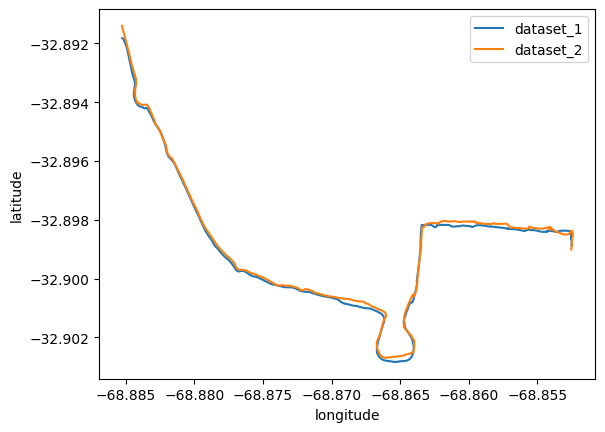

In [4]:
subtract_g = True
fs_acc = 100 # sps


def load_dataset_n(path_n: str, i_ini: int, i_fin: int, n_dataset: int = 0, subtract_g: bool = True, plot: bool = True):
    acc_orig_df_n = pd.read_csv(path.join(source_path, path_n, "AccelerometerUncalibrated.csv")).iloc[i_ini*fs_acc:i_fin*fs_acc, :].reset_index()
    if subtract_g:
        acc_orig_df_n['z'] = acc_orig_df_n['z'] - 9.81
    loc_orig_df_n = pd.read_csv(path.join(source_path, path_n, "Location.csv")).iloc[i_ini:i_fin, :].reset_index()
    loc_orig_df_n = loc_orig_df_n.loc[loc_orig_df_n['speed'] > speed_stopped_th].reset_index()

    if plot and 'loc_orig_df_1' in globals():
        plt.plot(loc_orig_df_1['longitude'], loc_orig_df_1['latitude'], label='dataset_1')
        plt.plot(loc_orig_df_n['longitude'], loc_orig_df_n['latitude'], label=f'dataset_{n_dataset}')
        plt.xlabel('longitude')
        plt.ylabel('latitude')
        plt.legend()
        plt.show()

    return loc_orig_df_n, acc_orig_df_n


# Dataset 1
i_ini, i_fin = 0, 690 # s
loc_orig_df_1, acc_orig_df_1 = load_dataset_n('913_3', i_ini, i_fin, 1, plot=False)

# Dataset 2
i_ini, i_fin = 35, 800 # s
loc_orig_df_2, acc_orig_df_2 = load_dataset_n('913_2', i_ini, i_fin, 2, plot=True)



## Raw Visualization

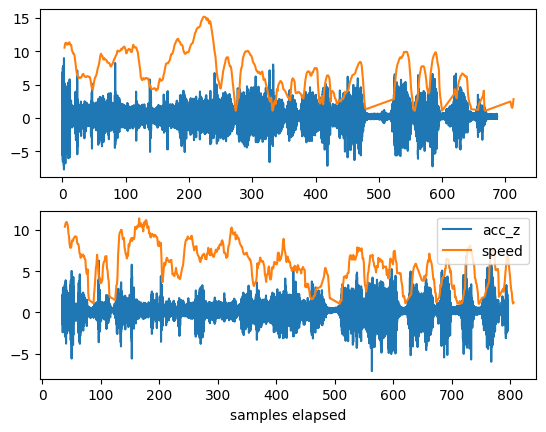

In [5]:
fig, ax = plt.subplots(2, 1, sharey='row')
ax[0].plot(acc_orig_df_1['seconds_elapsed'], acc_orig_df_1['z'])
ax[0].plot(loc_orig_df_1['seconds_elapsed'], loc_orig_df_1['speed'])
ax[1].plot(acc_orig_df_2['seconds_elapsed'], acc_orig_df_2['z'], label='acc_z')
ax[1].plot(loc_orig_df_2['seconds_elapsed'], loc_orig_df_2['speed'], label='speed')
ax[1].set_xlabel('samples elapsed')
ax[1].legend()

# Feature extraction

Global spectrum

Text(0.5, 0, 'Frequency [Hz]')

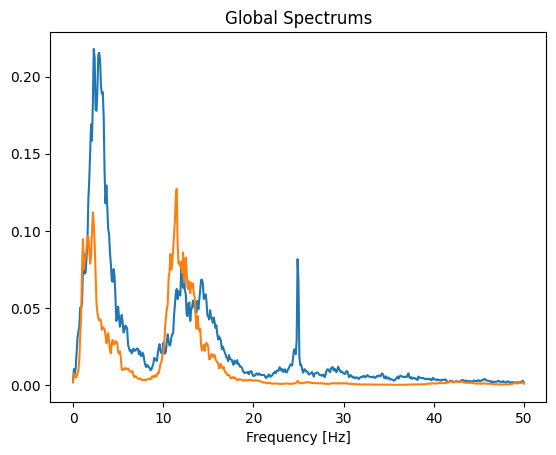

In [6]:
f = np.linspace(0, fs_acc/2, win_len//2 + 1)
global_spectrum_1 = signal.welch(acc_orig_df_1['z'].values, fs=fs_acc, nperseg=win_len, noverlap=win_len//2)[1]
global_spectrum_2 = signal.welch(acc_orig_df_2['z'].values, fs=fs_acc, nperseg=win_len, noverlap=win_len//2)[1]
fig, ax = plt.subplots(1, 1, sharex='col')
ax.plot(f, global_spectrum_1, label='global spectrum 1')
ax.plot(f, global_spectrum_2, label='global spectrum 2')
ax.set_title('Global Spectrums')
ax.set_xlabel('Frequency [Hz]')

## Spectrograms

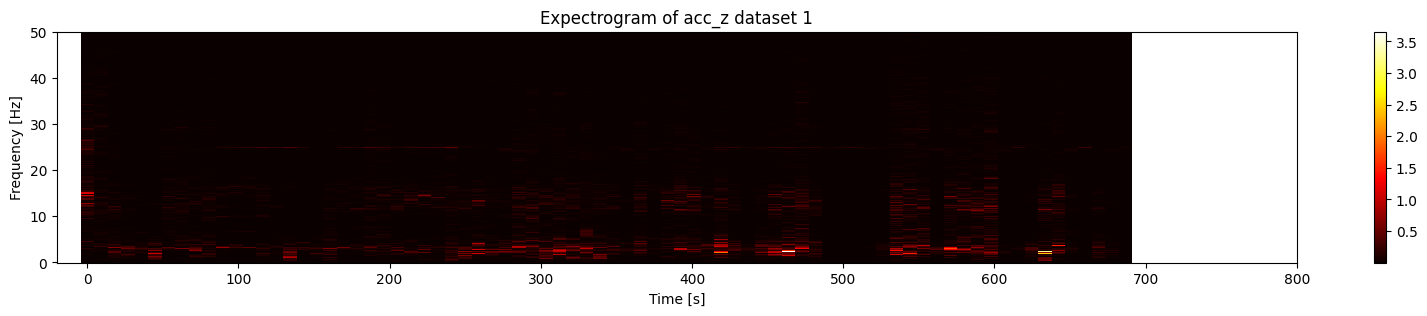

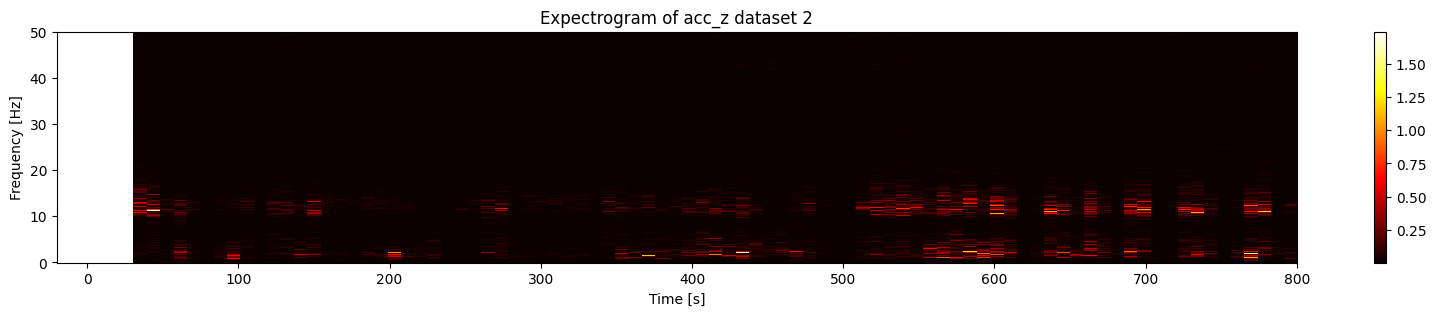

In [7]:
# plot expectrograms of acc_z
# Expectrograms

def plot_spectrogram(spectrogram_, ax=None, tlim=None, flim=None, title=None, spatial=False, x_index=False):
    f, t, Sxx = spectrogram_
    if x_index:
        t = np.arange(len(t))
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 3))
    im = ax.pcolormesh(t, f, Sxx, shading=None, cmap='hot')
    ax.set_ylabel('Frequency [Hz]' if not spatial else 'Spatial frequency [1/m]')
    ax.set_xlabel('Time [s]' if not x_index else 'Sample index')
    fig.colorbar(im, ax=ax)
    if tlim is not None:
        ax.set_xlim(tlim)
    if flim is not None:
        ax.set_ylim(flim)
    ax.set_title(title if title else 'Spectrogram')

    return ax

def get_spectrogram(acc_orig_df_n, fs, win_len):
    # Compute the spectrogram
    f, t, Sxx = signal.spectrogram(acc_orig_df_n['z'], fs=fs, nperseg=win_len)
    # Correct the time vector using seconds_elapsed
    t = np.interp(t, np.linspace(t[0], t[-1], len(acc_orig_df_n['seconds_elapsed'])), acc_orig_df_n['seconds_elapsed'])
    return (f, t, Sxx)

spectrogram_1 = get_spectrogram(acc_orig_df_1, fs=fs_acc, win_len=win_len)
spectrogram_2 = get_spectrogram(acc_orig_df_2, fs=fs_acc, win_len=win_len)

tmax = 800
tlim = (-20, tmax)
ax = plot_spectrogram(spectrogram_1, tlim=tlim, title='Expectrogram of acc_z dataset 1')
ax_ = plot_spectrogram(spectrogram_2, tlim=tlim, title='Expectrogram of acc_z dataset 2')

Normalized spectrograms

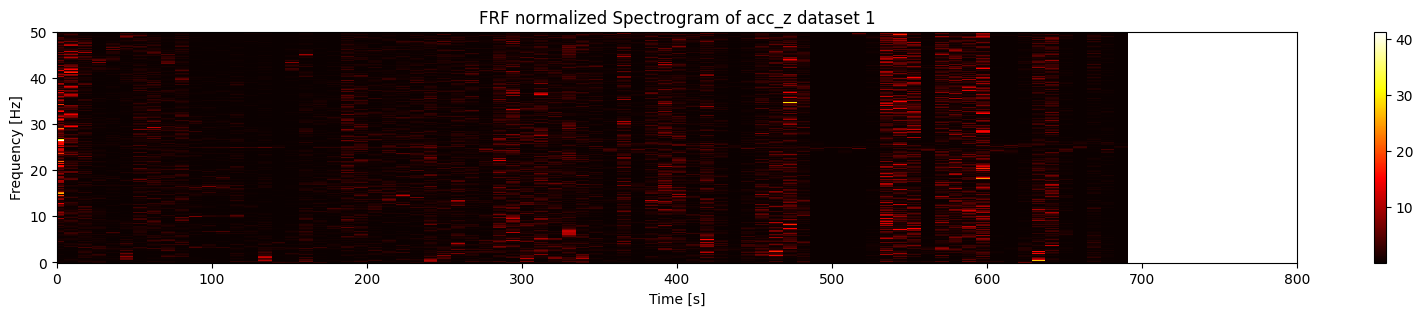

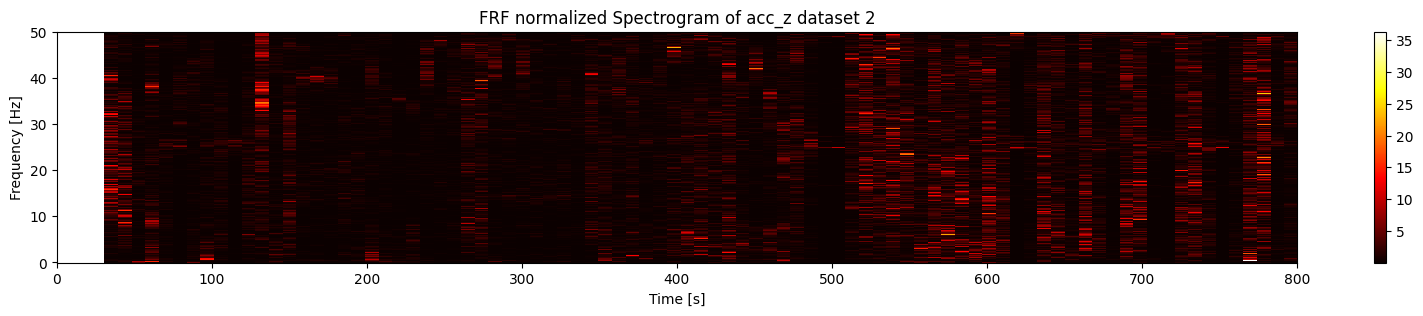

In [8]:
spectrogram_1_norm = (spectrogram_1[0], spectrogram_1[1], spectrogram_1[2]/global_spectrum_1.reshape(-1, 1))
spectrogram_2_norm = (spectrogram_2[0], spectrogram_2[1], spectrogram_2[2]/global_spectrum_2.reshape(-1, 1))

tmax = 800
ax = plot_spectrogram(spectrogram_1_norm, tlim=(0, tmax), title='FRF normalized Spectrogram of acc_z dataset 1')
ax_ = plot_spectrogram(spectrogram_2_norm, tlim=(0, tmax), title='FRF normalized Spectrogram of acc_z dataset 2')

## Spatial Spectrograms
$f = \text{temporal frequency}$

$f_s = \text{spatial frequency}$

$v = \text{vehicle speed}$

$f = v f_s$

(0.0, 800.0)

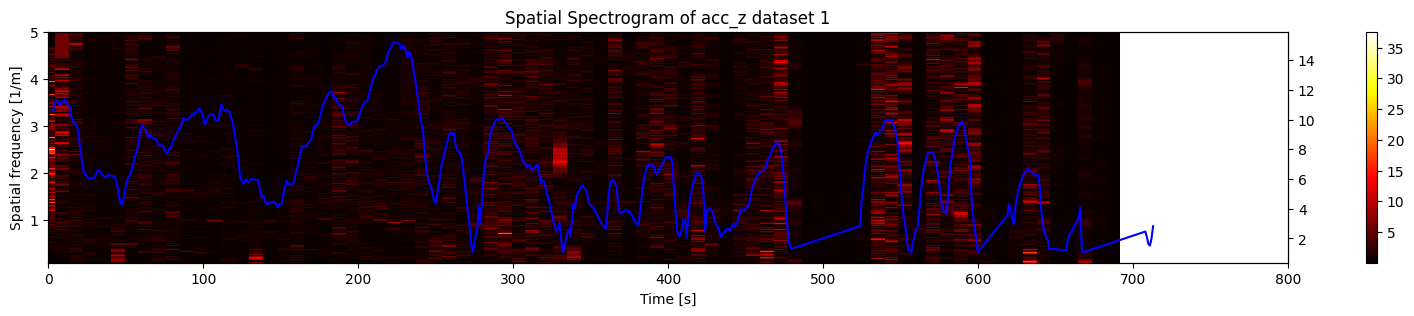

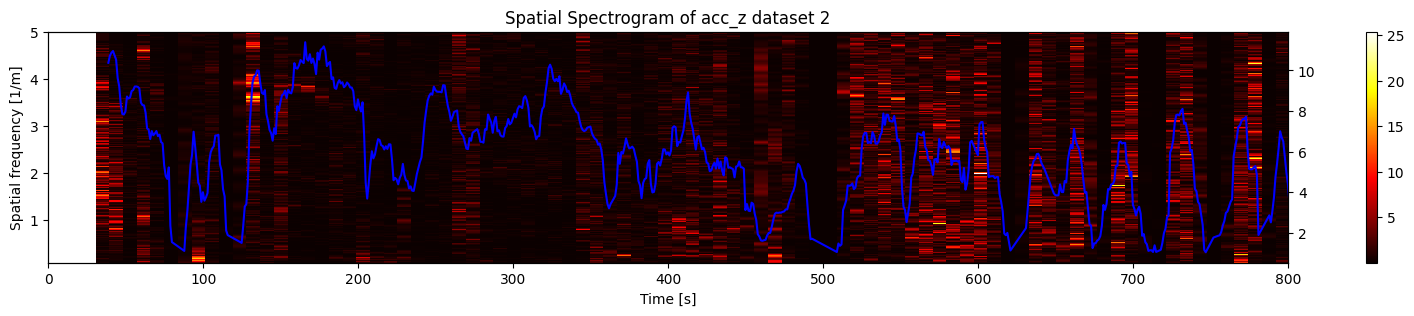

In [8]:
from typing import Union
min_wl = 0.2  # meter
max_wl = 10.0  # meter

def get_spatial_spectrogram(spectrogram: tuple, tv: np.ndarray, min_wl: float, max_wl: float) -> tuple:
    spatial_frequencies = np.linspace(1/max_wl, 1/min_wl, len(spectrogram[0]))
    f, t, Sxx = spectrogram
    Sxx_spatial = 0 * Sxx
    for i, t_ in enumerate(t):
        Sxx_spatial[:, i] = np.interp(np.interp(t_, tv[:,0], tv[:,1])*spatial_frequencies, f, Sxx[:, i])
    return spatial_frequencies, t, Sxx_spatial

spatial_spectrogram_1_norm = get_spatial_spectrogram(spectrogram_1_norm, loc_orig_df_1[['seconds_elapsed', 'speed']].values, min_wl, max_wl)
spatial_spectrogram_2_norm = get_spatial_spectrogram(spectrogram_2_norm, loc_orig_df_2[['seconds_elapsed', 'speed']].values, min_wl, max_wl)

# Plots
tlim = (0, tmax)
ax = plot_spectrogram(spatial_spectrogram_1_norm, tlim=tlim, title='Spatial Spectrogram of acc_z dataset 1', spatial=True)
ax_twin = ax.twinx()
ax_twin.plot(loc_orig_df_1['seconds_elapsed'], loc_orig_df_1['speed'], color='blue', label='speed 1')
ax_twin.set_xlim(tlim)
ax_ = plot_spectrogram(spatial_spectrogram_2_norm, tlim=tlim, title='Spatial Spectrogram of acc_z dataset 2', spatial=True)
ax_twin_ = ax_.twinx()
ax_twin_.plot(loc_orig_df_2['seconds_elapsed'], loc_orig_df_2['speed'], color='blue', label='speed 1')
ax_twin_.set_xlim(tlim)

In [9]:
# RMS of acceleration
def rolling_rms(acc_orig_df):
    acc2_cum = np.cumsum(acc_orig_df['z']**2)
    acc_rms = np.zeros(acc_orig_df.shape[0])
    for i in range(acc_orig_df.shape[0]-win_len):
        acc_rms[i+win_len] = np.sqrt((acc2_cum[i+win_len] - acc2_cum[i])/win_len)
    acc_feat_df = pd.DataFrame(data=np.vstack((acc_orig_df['seconds_elapsed'].values, acc_rms)).T, 
                                columns=['seconds_elapsed', 'z_rolling_rms']).fillna(0)
    acc_feat_df.reset_index(inplace=True)
    first_non_zero = np.nonzero(acc_feat_df['z_rolling_rms'].values)[0][0]
    acc_feat_df['z_rolling_rms'].values[:first_non_zero] = acc_feat_df['z_rolling_rms'].values[first_non_zero]
    return acc_feat_df

acc_feat_df_1, acc_feat_df_2 = rolling_rms(acc_orig_df_1), rolling_rms(acc_orig_df_2)


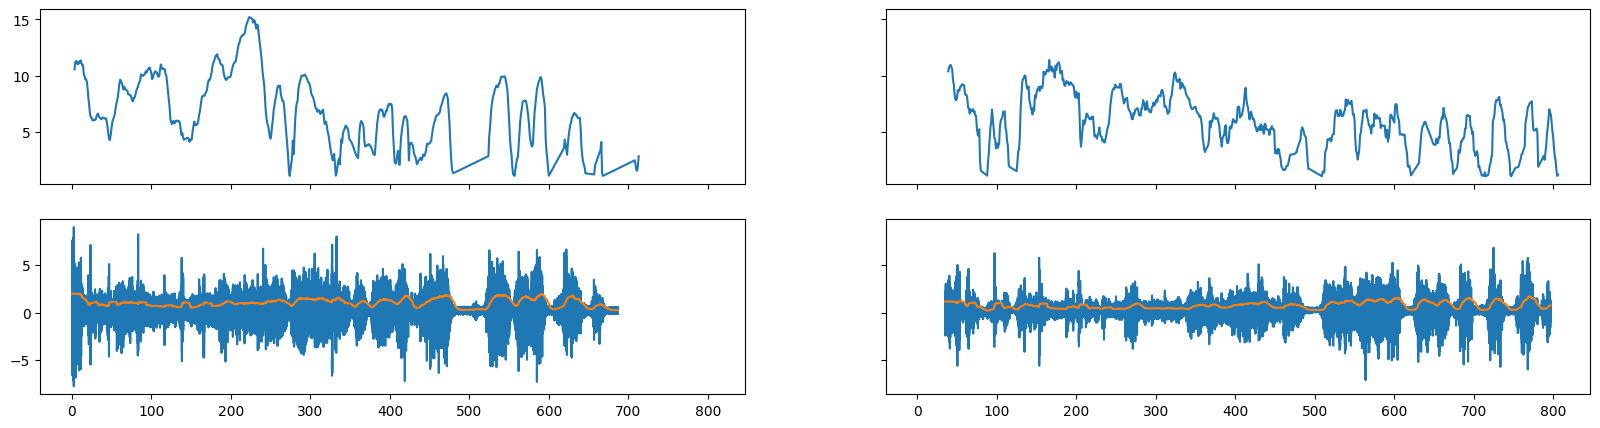

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(20, 5), sharex='all', sharey='row')
ax[0,0].plot(loc_orig_df_1['seconds_elapsed'], loc_orig_df_1['speed'])
ax[1,0].plot(acc_orig_df_1['seconds_elapsed'], acc_orig_df_1['z'])
ax[1,0].plot(acc_feat_df_1['seconds_elapsed'], acc_feat_df_1['z_rolling_rms'])
# ax[1,0].set_xlim([0, 200])
ax[0,1].plot(loc_orig_df_2['seconds_elapsed'], loc_orig_df_2['speed'])
ax[1,1].plot(acc_orig_df_2['seconds_elapsed'], acc_orig_df_2['z'])
ax[1,1].plot(acc_feat_df_2['seconds_elapsed'], acc_feat_df_2['z_rolling_rms'])
# ax[1,1].set_xlim([0, 60])
plt.show()

### Low frequency features

In [11]:
def calc_features_lf_n(loc_orig_df_n, acc_feat_df_n, spectrogram_, spatial_spectrogram_):
    features_lf_n = loc_orig_df_n.loc[:, :]
    features_lf_n['z_rolling_rms'] = \
    np.interp(x=loc_orig_df_n['seconds_elapsed'], 
              xp=acc_feat_df_n['seconds_elapsed'].values-((win_len/fs_acc)/2), fp=acc_feat_df_n['z_rolling_rms'])
    features_lf_n = features_lf_n.drop(columns=['level_0']).reset_index()

    # add spectrogram features (1 column for each frequency bin)
    f, t, Sxx = spectrogram_
    interp_spectrogram = np.array([
        np.interp(x=loc_orig_df_n['seconds_elapsed'], xp=t, fp=Sxx[i])
        for i in range(Sxx.shape[0])
    ])

    spectro_cols = [f'spectrogram_{f[i]}Hz' for i in range(Sxx.shape[0])]
    spectro_df = pd.DataFrame(interp_spectrogram.T, columns=spectro_cols)

    features_lf_n = pd.concat([features_lf_n.reset_index(drop=True), spectro_df], axis=1)

    # add spatial spectrogram (1 column for each spatial frequency bin)
    fs, t, Sxx_spatial = spatial_spectrogram_
    interp_spectrogram_spatial = np.array([
        np.interp(x=loc_orig_df_n['seconds_elapsed'], xp=t, fp=Sxx_spatial[i])
        for i in range(Sxx_spatial.shape[0])
    ])
    spectro_cols_spatial = [f'spatial_spectrogram_{fs[i]}/m' for i in range(Sxx_spatial.shape[0])]
    spectro_df_spatial = pd.DataFrame(interp_spectrogram_spatial.T, columns=spectro_cols_spatial)
    
    features_lf_n = pd.concat([features_lf_n.reset_index(drop=True), spectro_df_spatial], axis=1)

    return features_lf_n


features_lf_1 = calc_features_lf_n(loc_orig_df_1, acc_feat_df_1, spectrogram_1_norm, spatial_spectrogram_1_norm) 
features_lf_2 = calc_features_lf_n(loc_orig_df_2, acc_feat_df_2, spectrogram_2_norm, spatial_spectrogram_2_norm)


# fig, ax = plt.subplots(2, 2, figsize=(20, 10), sharex='all', sharey='row')
# ax[0,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['speed'])
# ax[0,0].set_ylabel('speed (m/s)')
# ax[1,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['z_rolling_rms'])
# ax[1,0].set_ylabel('rms acc. (m/s$^2$)')
# ax[0,1].plot(features_lf_2['seconds_elapsed'], features_lf_2['speed'])
# ax[1,1].plot(features_lf_2['seconds_elapsed'], features_lf_2['z_rolling_rms'])
# ax[1,0].set_xlabel('time (s)')
# ax[1,1].set_xlabel('time (s)')
# plt.show()

# fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex='all', sharey='all')
# ax[0].plot(features_lf_1['z_rolling_rms'], features_lf_1['speed'], linestyle='-', marker='.')
# ax[0].set_xlabel('rms acc. (m/s$^2$)')
# ax[0].set_ylabel('speed (m/s)')
# ax[1].plot(features_lf_2['z_rolling_rms'], features_lf_2['speed'], linestyle='-', marker='.')
# ax[1].set_xlabel('rms acc. (m/s$^2$)')
# plt.show()

### Location matching

In [12]:
def times_matches_1_n(loc_orig_df_1, loc_orig_df_n, features_lf_n):
    # Extract coordinates as arrays
    coords_orig = loc_orig_df_1[['latitude', 'longitude']].values
    coords_dest = loc_orig_df_n[['latitude', 'longitude']].values

    # Compute pairwise distances
    distances = cdist(coords_orig, coords_dest, metric='euclidean')

    # Find the nearest point for each origin point
    nearest_indices = distances.argmin(axis=1)
    nearest_distances = distances.min(axis=1)

    # Build a dictionary of time matches
    time_matches_dict = {}
    for i, (dist, idx) in enumerate(zip(nearest_distances, nearest_indices)):
        orig_time = loc_orig_df_1.iloc[i]['seconds_elapsed']
        dest_time = loc_orig_df_n.iloc[idx]['seconds_elapsed']
        time_matches_dict[orig_time] = dest_time

    # location matching
    loc_orig_df_n_matched = loc_orig_df_1.copy()
    for index, row in loc_orig_df_1.iterrows():
        seconds_elapsed_1 = row['seconds_elapsed']
        if index == len(loc_orig_df_n_matched):
            break
        loc_orig_df_n_matched.iloc[index] = loc_orig_df_n.loc[loc_orig_df_n['seconds_elapsed'] == time_matches_dict[seconds_elapsed_1]].values[0]

    # feature matching
    features_lf_n_matched = features_lf_1.copy()
    for index, row in features_lf_1.iterrows():
        seconds_elapsed_1 = row['seconds_elapsed']
        features_lf_n_matched.iloc[index] = features_lf_n.loc[features_lf_n['seconds_elapsed'] == time_matches_dict[seconds_elapsed_1]].values[0]

    return time_matches_dict, loc_orig_df_n_matched, features_lf_n_matched


time_matches_dict, loc_orig_df_2_matched, features_lf_2_matched = times_matches_1_n(loc_orig_df_1, loc_orig_df_2, features_lf_2)


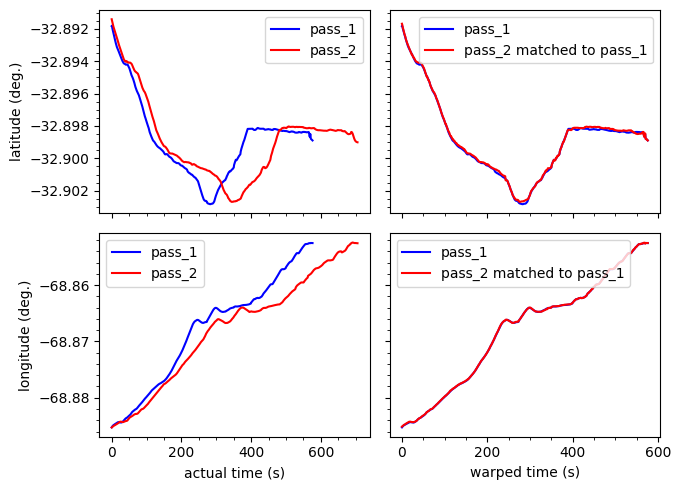

In [13]:

fig, ax = plt.subplots(2, 2, figsize=(7, 5), sharey='row', sharex='col')

ax[0,0].plot(loc_orig_df_1['latitude'].values, color='blue', label='pass_1')
ax[0,0].plot(loc_orig_df_2['latitude'].values, color='red', label='pass_2')
ax[1,0].plot(loc_orig_df_1['longitude'].values, color='blue', label='pass_1')
ax[1,0].plot(loc_orig_df_2['longitude'].values, color='red',  label='pass_2')


ax[0,1].plot(loc_orig_df_1['latitude'].values, color='blue', label='pass_1')
ax[0,1].plot(loc_orig_df_2_matched['latitude'].values, color='red',  label='pass_2 matched to pass_1')
ax[1,1].plot(loc_orig_df_1['longitude'].values, color='blue', label='pass_1')
ax[1,1].plot(loc_orig_df_2_matched['longitude'].values, color='red',  label='pass_2 matched to pass_1')

ax[0,0].set_ylabel('latitude (deg.)')
ax[1,0].set_ylabel('longitude (deg.)')
ax[1,0].set_xlabel('actual time (s)')
ax[1,1].set_xlabel('warped time (s)')

for __ in ax:
    for _ in __:
        _.minorticks_on()
        _.legend()

fig.tight_layout()
plt.show()
fig.savefig('location_based_dtw.pdf')

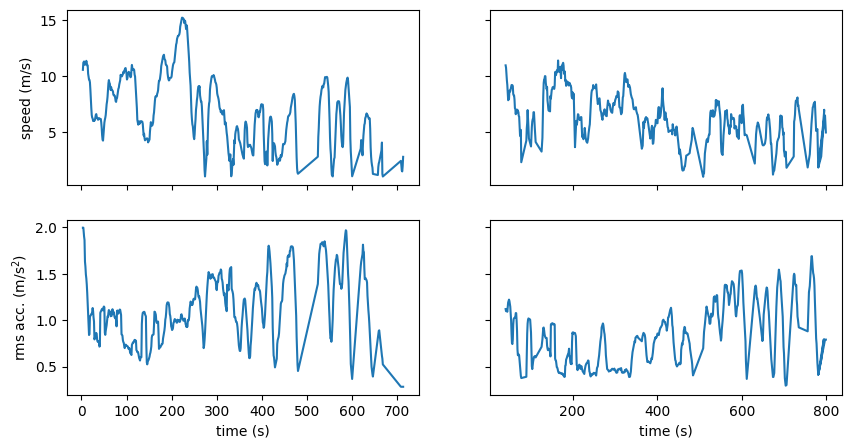

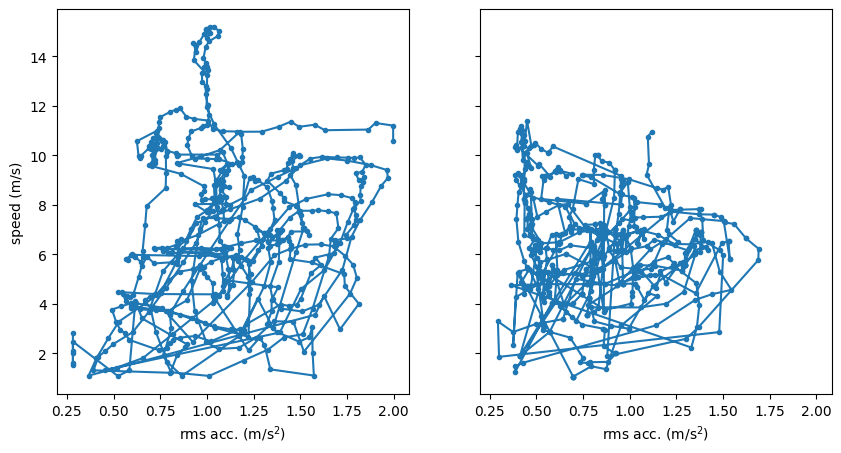

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(10, 5), sharex='col', sharey='row')
ax[0,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['speed'])
ax[0,0].set_ylabel('speed (m/s)')
ax[1,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['z_rolling_rms'])
ax[0,1].plot(features_lf_2_matched['seconds_elapsed'], features_lf_2_matched['speed'])
ax[1,1].plot(features_lf_2_matched['seconds_elapsed'], features_lf_2_matched['z_rolling_rms'])
ax[1,0].set_ylabel('rms acc. (m/s$^2$)')
ax[1,0].set_xlabel('time (s)')
ax[1,1].set_xlabel('time (s)')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex='all', sharey='all')
ax[0].plot(features_lf_1['z_rolling_rms'], features_lf_1['speed'], linestyle='-', marker='.')
ax[0].set_xlabel('rms acc. (m/s$^2$)')
ax[0].set_ylabel('speed (m/s)')
ax[1].plot(features_lf_2_matched['z_rolling_rms'], features_lf_2_matched['speed'], linestyle='-', marker='.')
ax[1].set_xlabel('rms acc. (m/s$^2$)')
plt.show()

# Matched spectrograms

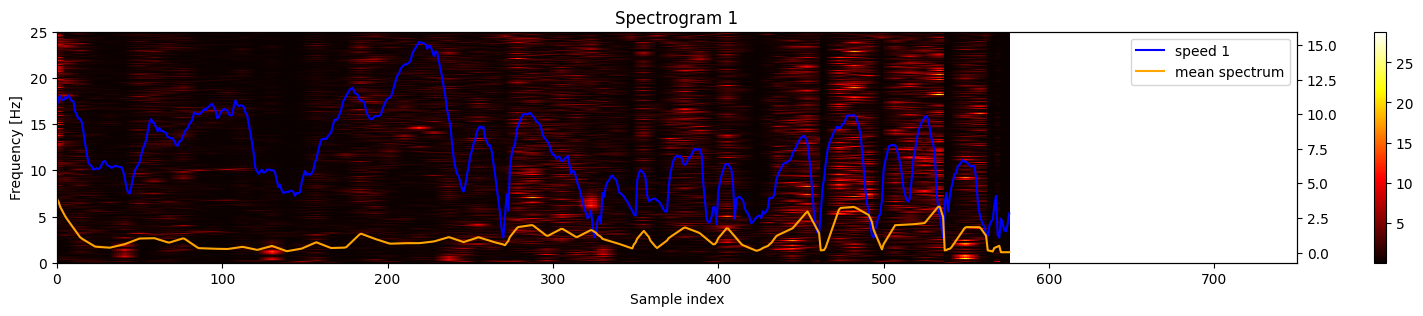

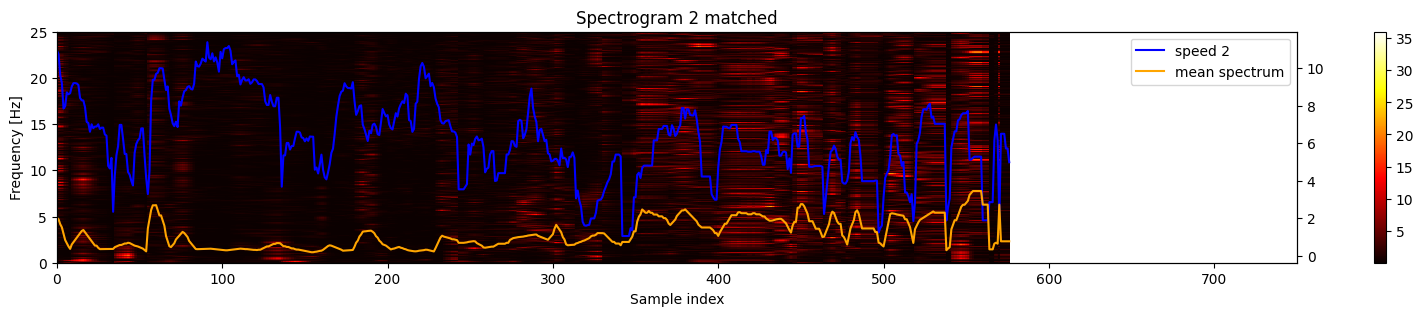

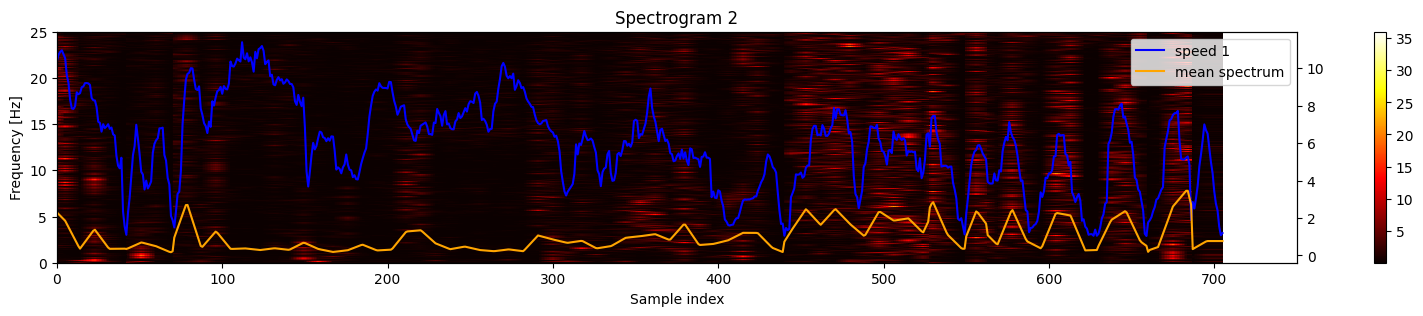

In [15]:
# Matched spectrograms

spectrogram_from_lf_1_ = features_lf_1.loc[:, ['seconds_elapsed'] + [col for col in features_lf_1.columns if ('spectrogram_' in col and 'Hz' in col)]].values
spectrogram_from_lf_1 = (np.linspace(0, fs_acc/2, spectrogram_from_lf_1_.shape[1]-1), spectrogram_from_lf_1_[:,0], spectrogram_from_lf_1_[:, 1:].T)
spectrogram_from_lf_2_ = features_lf_2.loc[:, ['seconds_elapsed'] + [col for col in features_lf_2.columns if ('spectrogram_' in col and 'Hz' in col)]].values
spectrogram_from_lf_2 = (np.linspace(0, fs_acc/2, spectrogram_from_lf_2_.shape[1]-1), spectrogram_from_lf_2_[:,0], spectrogram_from_lf_2_[:, 1:].T)
spectrogram_from_lf_2_matched_ = features_lf_2_matched.loc[:, ['seconds_elapsed'] + [col for col in features_lf_2_matched.columns if ('spectrogram_' in col and 'Hz' in col)]].values
spectrogram_from_lf_2_matched = (np.linspace(0, fs_acc/2, spectrogram_from_lf_2_matched_.shape[1]-1), spectrogram_from_lf_1_[:,0], spectrogram_from_lf_2_matched_[:, 1:].T)

tmax = 750
ax = plot_spectrogram(spectrogram_from_lf_1, tlim=(0, tmax), flim=(0, 25), title='Spectrogram 1', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_1['speed'], color='blue', label='speed 1')
ax_twin.plot(np.mean(spectrogram_from_lf_1[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()
ax = plot_spectrogram(spectrogram_from_lf_2_matched, tlim=(0, tmax), flim=(0, 25), title='Spectrogram 2 matched', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2_matched['speed'], color='blue', label='speed 2')
ax_twin.plot(np.mean(spectrogram_from_lf_2_matched[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()
ax = plot_spectrogram(spectrogram_from_lf_2, tlim=(0, tmax), flim=(0, 25), title='Spectrogram 2', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2['speed'], color='blue', label='speed 1')
ax_twin.plot(np.mean(spectrogram_from_lf_2[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()


## Velocity normalized spectrograms

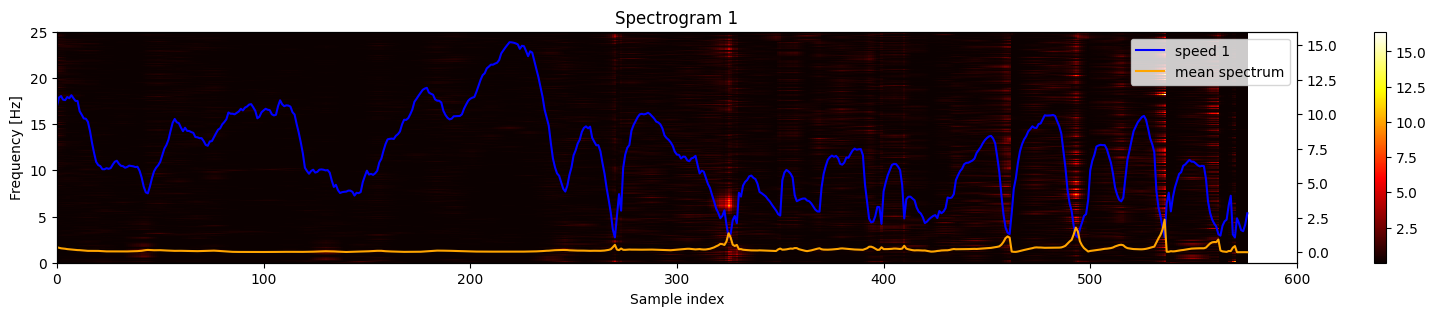

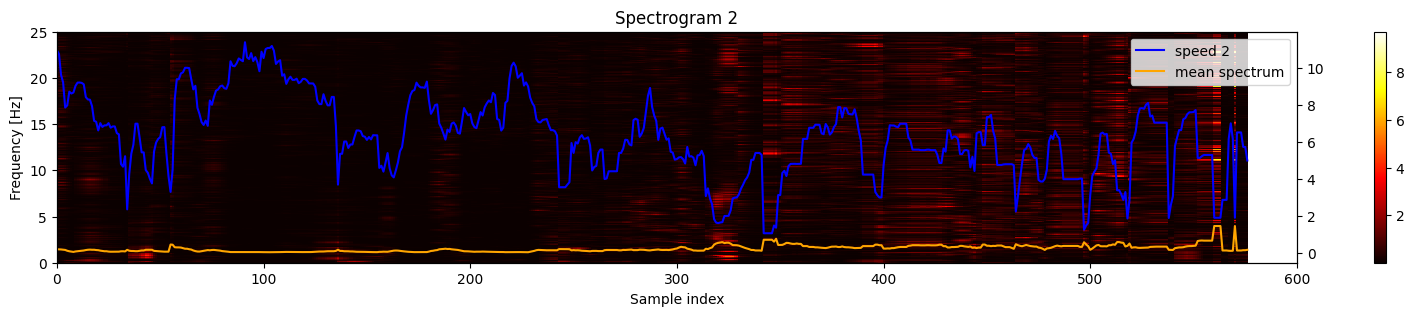

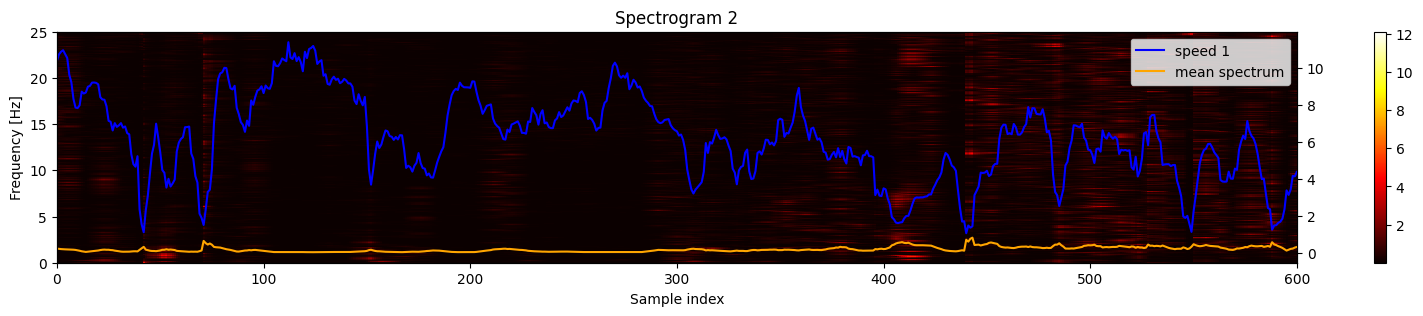

In [ ]:
spectrogram_from_lf_1_vel_norm = (
    spectrogram_from_lf_1[0], spectrogram_from_lf_1[1], 
    spectrogram_from_lf_1[2] / features_lf_1['speed'].values.reshape(1, -1)
    )
spectrogram_from_lf_2_matched_vel_norm = (
    spectrogram_from_lf_2_matched[0], spectrogram_from_lf_2_matched[1], 
    spectrogram_from_lf_2_matched[2] / features_lf_2_matched['speed'].values.reshape(1, -1)
    )
spectrogram_from_lf_2_vel_norm = (
    spectrogram_from_lf_2[0], spectrogram_from_lf_2[1], 
    spectrogram_from_lf_2[2] / features_lf_2['speed'].values.reshape(1, -1)
    )

ilim = (0, 600)
ax = plot_spectrogram(spectrogram_from_lf_1_vel_norm, tlim=ilim, flim=(0, 25), title='Spectrogram 1', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_1['speed'], color='blue', label='speed 1')
ax_twin.plot(np.mean(spectrogram_from_lf_1_vel_norm[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()

ax = plot_spectrogram(spectrogram_from_lf_2_matched_vel_norm, tlim=ilim, flim=(0, 25), title='Spectrogram 2 matched', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2_matched['speed'], color='blue', label='speed 2')
ax_twin.plot(np.mean(spectrogram_from_lf_2_matched_vel_norm[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()

ax = plot_spectrogram(spectrogram_from_lf_2_vel_norm, tlim=ilim, flim=(0, 25), title='Spectrogram 2', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2['speed'], color='blue', label='speed 1')
ax_twin.plot(np.mean(spectrogram_from_lf_2_vel_norm[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()

## Matched Spatial spectrograms
$\frac{1}{s} \frac{s}{m}=\frac{1}{m}$


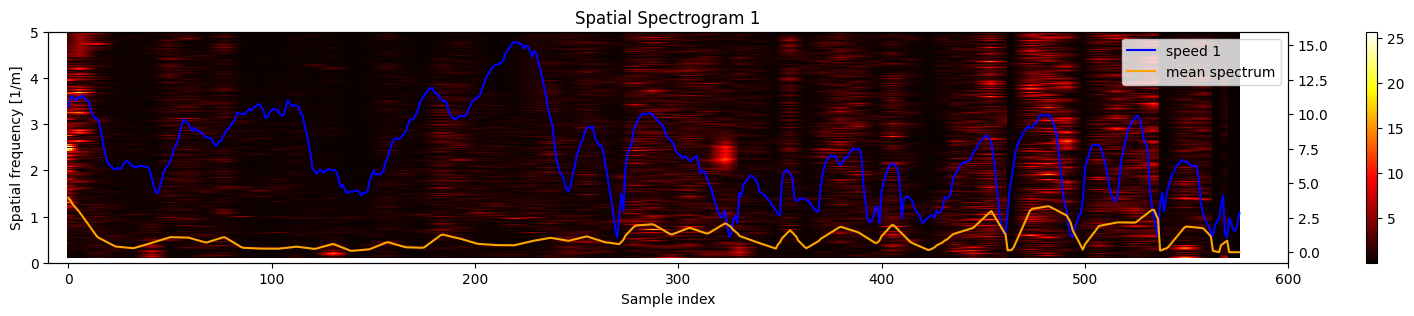

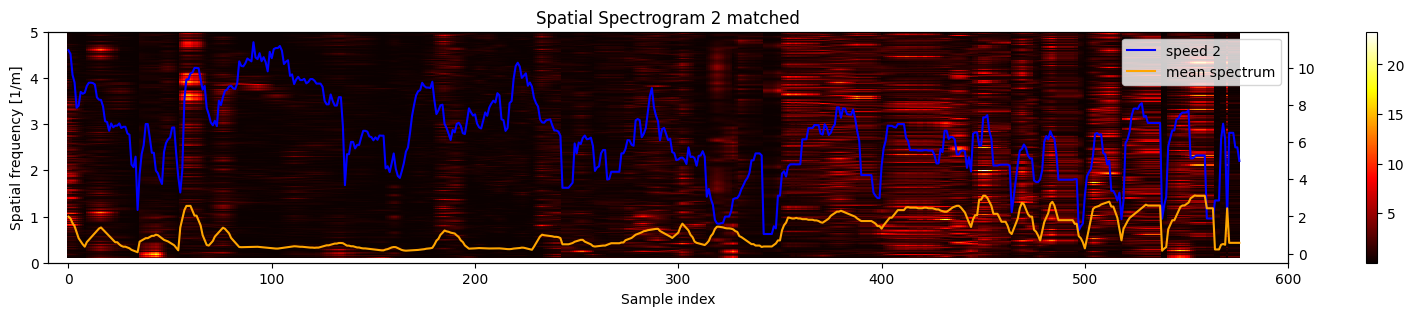

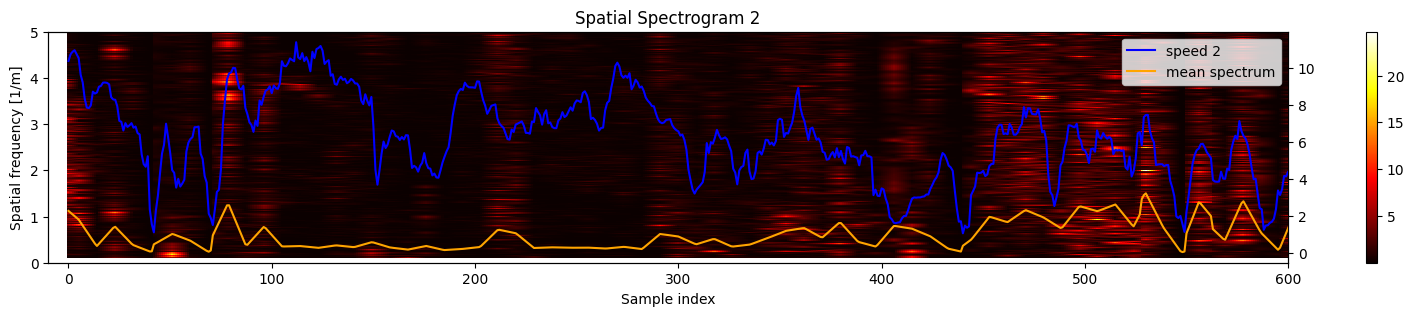

In [17]:
# Matched spatial spectrograms

spatial_spectrogram_from_lf_1_ = features_lf_1.loc[:, ['seconds_elapsed'] + [col for col in features_lf_1.columns if 'spatial_spectrogram_' in col]].values
spatial_spectrogram_from_lf_1 = (np.linspace(1/max_wl, 1/min_wl, spatial_spectrogram_from_lf_1_.shape[1]-1), spatial_spectrogram_from_lf_1_[:,0], spatial_spectrogram_from_lf_1_[:, 1:].T)
spatial_spectrogram_from_lf_2_ = features_lf_2.loc[:, ['seconds_elapsed'] + [col for col in features_lf_2.columns if 'spatial_spectrogram_' in col]].values
spatial_spectrogram_from_lf_2 = (np.linspace(1/max_wl, 1/min_wl, spatial_spectrogram_from_lf_2_.shape[1]-1), spatial_spectrogram_from_lf_2_[:,0], spatial_spectrogram_from_lf_2_[:, 1:].T)
spatial_spectrogram_from_lf_2_matched_ = features_lf_2_matched.loc[:, ['seconds_elapsed'] + [col for col in features_lf_2_matched.columns if 'spatial_spectrogram_' in col]].values
spatial_spectrogram_from_lf_2_matched = (np.linspace(1/max_wl, 1/min_wl, spatial_spectrogram_from_lf_2_matched_.shape[1]-1), spatial_spectrogram_from_lf_1_[:,0], spatial_spectrogram_from_lf_2_matched_[:, 1:].T)

tlim = (-10, 600)
ax = plot_spectrogram(spatial_spectrogram_from_lf_1, tlim=tlim, flim=(0, 5), title='Spatial Spectrogram 1', spatial=True, x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_1['speed'], color='blue', label='speed 1')
ax_twin.plot(np.mean(spatial_spectrogram_from_lf_1[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()
ax = plot_spectrogram(spatial_spectrogram_from_lf_2_matched, tlim=tlim, flim=(0, 5), title='Spatial Spectrogram 2 matched', spatial=True, x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2_matched['speed'], color='blue', label='speed 2')
ax_twin.plot(np.mean(spatial_spectrogram_from_lf_2_matched[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()
ax = plot_spectrogram(spatial_spectrogram_from_lf_2, tlim=tlim, flim=(0, 5), title='Spatial Spectrogram 2', spatial=True, x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2['speed'], color='blue', label='speed 2')
ax_twin.plot(np.mean(spatial_spectrogram_from_lf_2[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()

# Predict rms_acc as a function of speed for each place

## and spatial spectrogram

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [77]:
f, t, Sxx_spatial = spatial_spectrogram_from_lf_1
X_spatial = np.hstack((Sxx_spatial.T, features_lf_1[['speed']].values))
y = features_lf_1[['z_rolling_rms']].values / features_lf_1[['speed']].values
X_spatial.shape, y.shape

((577, 502), (577, 1))

In [79]:
# validation
X_spatial_train, X_spatial_test, y_train, y_test = train_test_split(
    X_spatial, y, test_size=0.2, random_state=123, shuffle=True
    )

# scaling
scaler_X_spatial = MinMaxScaler().fit(X_spatial)
scaler_y = MinMaxScaler().fit(y)

X_spatial_norm_train = scaler_X_spatial.transform(X_spatial_train)
X_spatial_norm_test = scaler_X_spatial.transform(X_spatial_test)
y_norm_train = scaler_y.transform(y_train)
y_norm_test = scaler_y.transform(y_test)

# model
model_spatial = RandomForestRegressor(n_estimators=10)
model_spatial.fit(X=X_spatial_norm_train, y=y_norm_train[:, 0])

RandomForestRegressor(n_estimators=10)

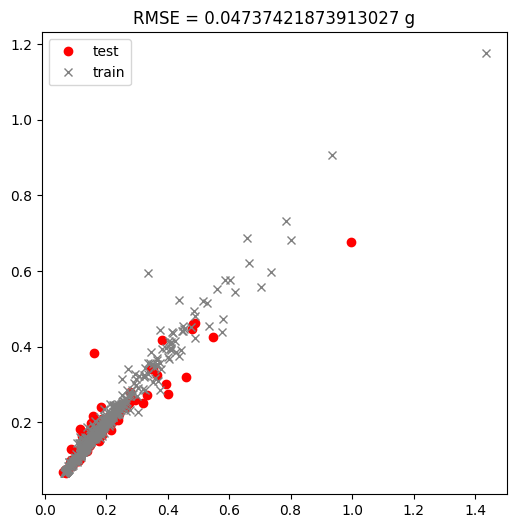

In [81]:
y_test_pred_spatial = scaler_y.inverse_transform(model_spatial.predict(X_spatial_norm_test).reshape(-1,1))
# plot
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.plot(scaler_y.inverse_transform(y_norm_test), y_test_pred_spatial, 
        color="red", label='test', linestyle='none', marker='o')
ax.plot(scaler_y.inverse_transform(y_norm_train), scaler_y.inverse_transform(model_spatial.predict(X_spatial_norm_train).reshape(-1,1)), 
        color="grey", label='train', linestyle='none', marker='x')
ax.legend()
ax.set_title('RMSE = ' + str(np.sqrt(mean_squared_error(y_test, y_test_pred_spatial))) + ' g')
plt.show()

## Validation with pass 2 (but spatial spectrogram of pass 1)

In [92]:
f, t, Sxx_spatial_val = spatial_spectrogram_from_lf_1
X_spatial_val = np.hstack((Sxx_spatial_val.T, features_lf_2_matched[['speed']].values))

acc2 = features_lf_2_matched[['z_rolling_rms']].values
acc1 = features_lf_1[['z_rolling_rms']].values

X_spatial_val.shape, y.shape

((577, 502), (577, 1))

In [93]:
X_spatial_norm_val = scaler_X_spatial.transform(X_spatial_val)


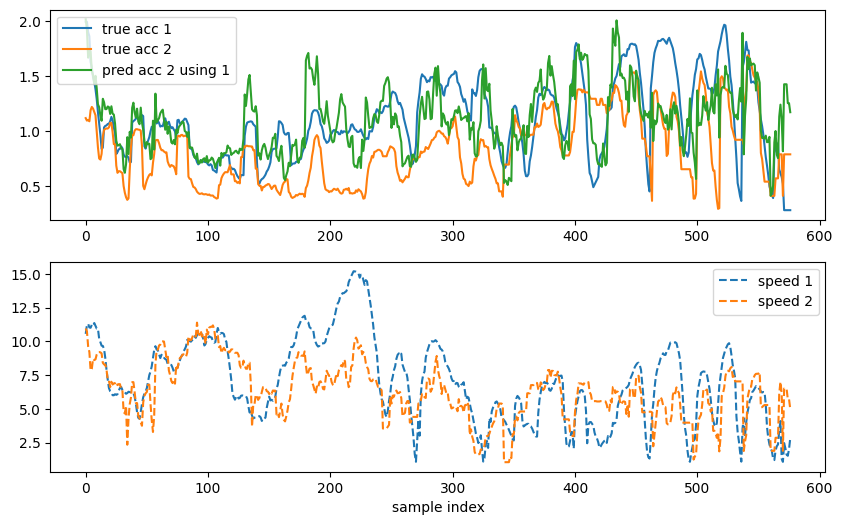

In [102]:
y_val_pred = scaler_y.inverse_transform(model_spatial.predict(X_spatial_norm_val).reshape(-1,1))

fig, ax = plt.subplots(2, 1, figsize=(10,6))
ax[0].plot(acc1, label="true acc 1")
ax[0].plot(acc2, label="true acc 2")
ax[0].plot(y_val_pred * features_lf_2_matched[['speed']].values, label="pred acc 2 using 1")
ax[1].plot(features_lf_1[['speed']].values, label="speed 1", linestyle='--')
ax[1].plot(features_lf_2_matched[['speed']].values, label="speed 2", linestyle='--')
ax[0].legend()
ax[1].legend()
ax[1].set_xlabel("sample index")
plt.show()


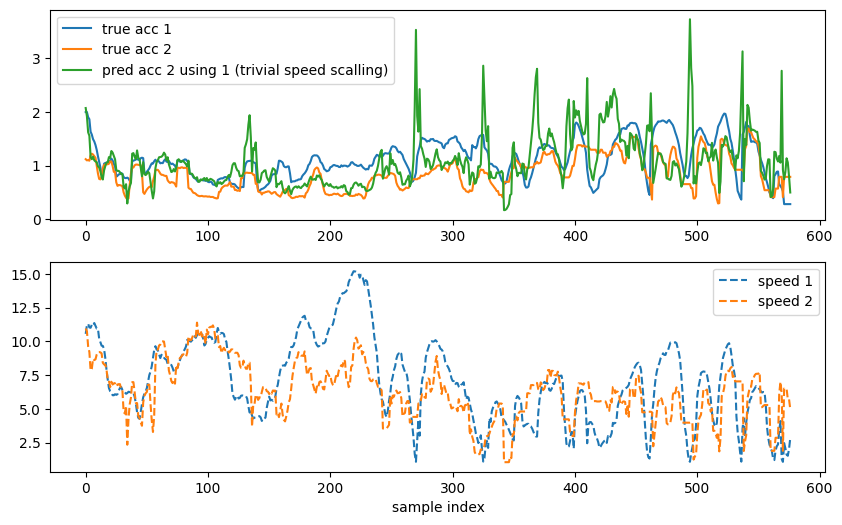

In [101]:
y_val_pred = scaler_y.inverse_transform(model_spatial.predict(X_spatial_norm_val).reshape(-1,1))

fig, ax = plt.subplots(2, 1, figsize=(10,6))
ax[0].plot(acc1, label="true acc 1")
ax[0].plot(acc2, label="true acc 2")
ax[0].plot(acc1 * features_lf_2_matched[['speed']].values / features_lf_1[['speed']].values, 
           label="pred acc 2 using 1 (trivial speed scalling)")
ax[1].plot(features_lf_1[['speed']].values, label="speed 1", linestyle='--')
ax[1].plot(features_lf_2_matched[['speed']].values, label="speed 2", linestyle='--')
ax[0].legend()
ax[1].legend()
ax[1].set_xlabel("sample index")
plt.show()


Comparison

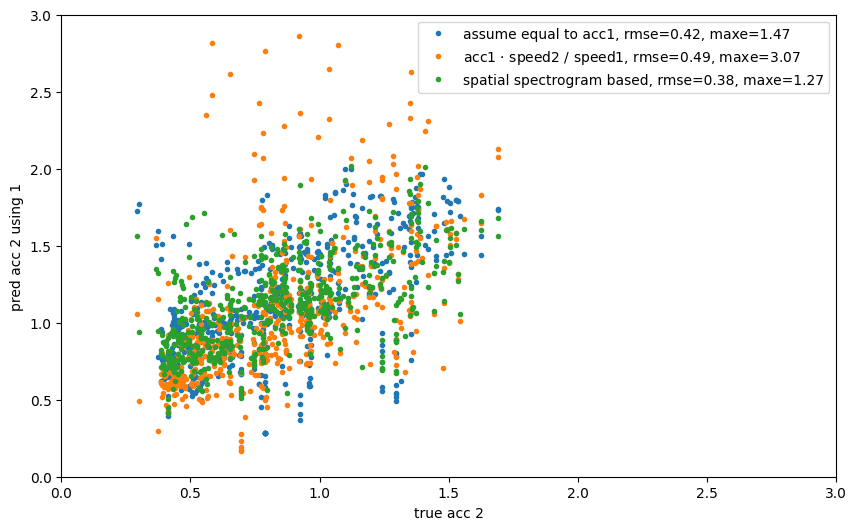

In [115]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))

rmse = np.round(np.sqrt(mean_squared_error(acc2, acc1)), 2)
maxe = np.round(np.max(np.abs(acc2 - acc1)), 2)
ax.plot(acc2, acc1, linestyle='none', marker='.',
        label=f'assume equal to acc1, {rmse=}, {maxe=}')

rmse = np.round(np.sqrt(mean_squared_error(acc2, acc1 * features_lf_2_matched[['speed']].values / features_lf_1[['speed']].values)), 2)
maxe = np.round(np.max(np.abs(acc2 - acc1 * features_lf_2_matched[['speed']].values / features_lf_1[['speed']].values)), 2)
ax.plot(acc2, acc1 * features_lf_2_matched[['speed']].values / features_lf_1[['speed']].values, linestyle='none', marker='.',
        label=f'acc1 $\cdot$ speed2 / speed1, {rmse=}, {maxe=}')

rmse = np.round(np.sqrt(mean_squared_error(acc2, y_val_pred * features_lf_2_matched[['speed']].values)), 2)
maxe = np.round(np.max(np.abs(acc2 - y_val_pred * features_lf_2_matched[['speed']].values)), 2)
ax.plot(acc2, y_val_pred * features_lf_2_matched[['speed']].values, linestyle='none', marker='.',
        label=f'spatial spectrogram based, {rmse=}, {maxe=}')

ax.set_xlabel('true acc 2'), 
ax.set_ylabel('pred acc 2 using 1')
ax.set_xlim((0,3))
ax.set_ylim((0,3))
ax.legend()
plt.show()

In [46]:
X_spatial.shape

(577, 502)

# Mean of FRF normalized - velocity normalized - spatial spectrograms

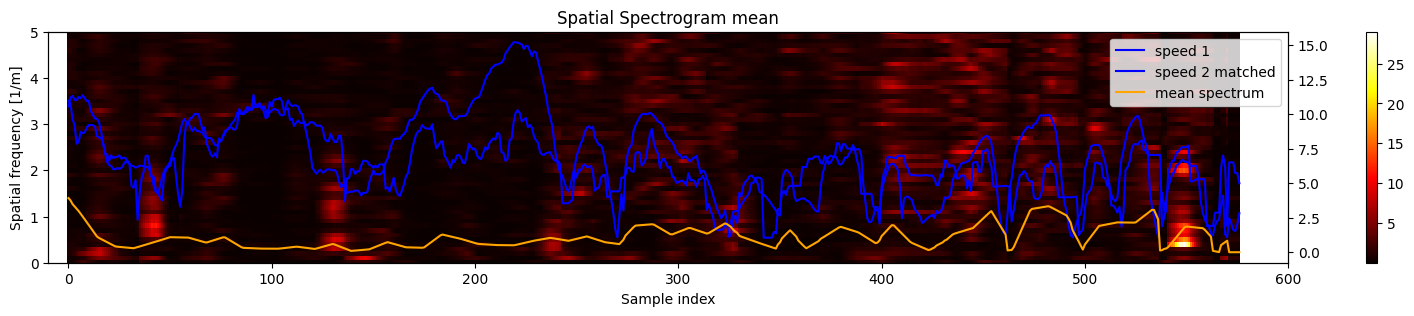

In [18]:
# Mean of FRF normalized - velocity normalized - spatial spectrograms
def get_mean_spectrogram(spectrograms: list) -> tuple:
    """
    Compute the mean of a list of spectrograms.
    Each spectrogram is a tuple (frequencies, times, Sxx).
    """
    frequencies = spectrograms[0][0]
    times = spectrograms[0][1]
    Sxx_mean = np.mean([s[2] for s in spectrograms], axis=0)
    return (frequencies, times, Sxx_mean)

mean_spectrogram = get_mean_spectrogram([spectrogram_from_lf_1, spectrogram_from_lf_2_matched])
ax = plot_spectrogram(mean_spectrogram, tlim=tlim, flim=(0, 5), title='Spatial Spectrogram mean', spatial=True, x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_1['speed'], color='blue', label='speed 1')
ax_twin.plot(features_lf_2_matched['speed'], color='blue', label='speed 2 matched')
ax_twin.plot(np.mean(spatial_spectrogram_from_lf_1[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()

## Plot some spatial spectra

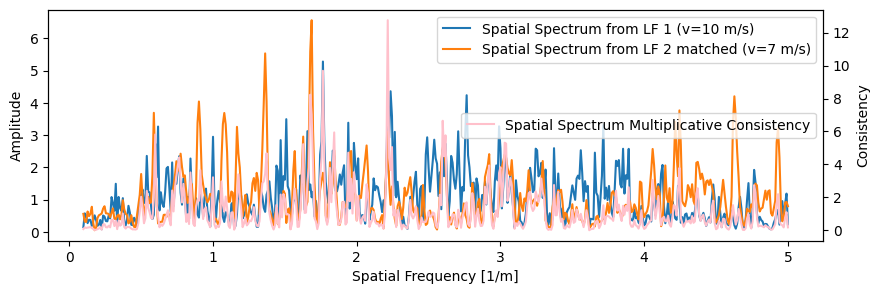

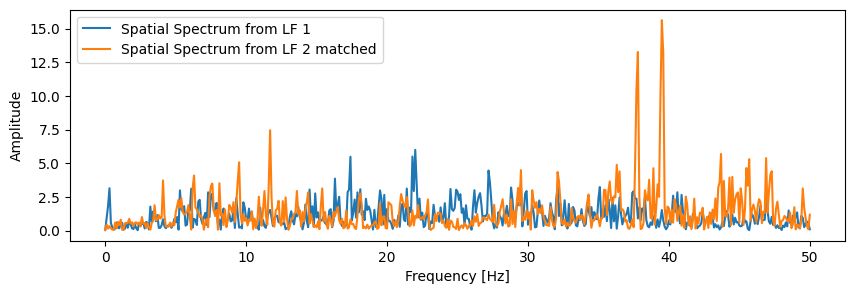

In [19]:
## Plot spatial spectra for a given time


t_plot = 540  # seconds

def plot_spectrum(spectrogram, t_plot, ax=None, label=None, idx_t=None, type_: str = 'spatial', color=None,
                  flim=None, linestyle=None):
    if label is None:
        label = f'Spectrum at {t_plot}s'
    fs, t, Sxx_spatial = spectrogram
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    if idx_t is None:
        idx_t = np.argmin(np.abs(t - t_plot))
    if color:
        ax.plot(fs, Sxx_spatial[:, idx_t], label=label, color=color)
    else:
        ax.plot(fs, Sxx_spatial[:, idx_t], label=label)
    if type_ == 'spectral':
        ax.set_xlabel('Frequency [Hz]')
    else:
        ax.set_xlabel('Spatial Frequency [1/m]')
    if flim is not None:
        ax.set_xlim(flim)
    if linestyle is not None:
        ax.lines[-1].set_linestyle(linestyle)
    ax.set_ylabel('Amplitude')
    ax.legend()

    return ax

idx_t = 190
idx_t = 190
ax = plot_spectrum(spatial_spectrogram_from_lf_1, t_plot, ax=None, 
                   label=f"Spatial Spectrum from LF 1 (v={round(features_lf_1['speed'][idx_t])} m/s)", idx_t=idx_t)
ax = plot_spectrum(spatial_spectrogram_from_lf_2_matched, t_plot, ax=ax, 
                   label=f"Spatial Spectrum from LF 2 matched (v={round(features_lf_2_matched['speed'][idx_t])} m/s)", idx_t=idx_t)

# Compute consistency spectrum
consistency_spectrum = spatial_spectrogram_from_lf_1[2][:, idx_t] * spatial_spectrogram_from_lf_2_matched[2][:, idx_t]
fs = spatial_spectrogram_from_lf_1[0]
ax_twin = ax.twinx()
ax_twin.set_ylabel('Consistency')
ax_twin.plot(fs, consistency_spectrum, label='Spatial Spectrum Multiplicative Consistency', color='pink')
ax_twin.legend(loc='right')


ax_ = plot_spectrum(spectrogram_from_lf_1, t_plot, ax=None, label='Spatial Spectrum from LF 1', idx_t=idx_t, type_='spectral')
ax_ = plot_spectrum(spectrogram_from_lf_2_matched, t_plot, ax=ax_, label='Spatial Spectrum from LF 2 matched', idx_t=idx_t, type_='spectral')

## Consistency

In [20]:
def spectrogram_multiplicative_consistency(spectrogram1, spectrogram2, freq_window=5, time_window=5, threshold=None):
    """
    Computes the consistency between two spectrograms using multiplication.

    Parameters:
    - f, t: frequency and time vectors.
    - Sxx1, Sxx2: spectrograms (shape: [n_frequencies, n_times]).
    - freq_window, time_window: size of the sliding window (in number of bins).
    - threshold: if specified, also returns a boolean mask indicating reliable regions.

    Returns:
    - f, t, C: matrix of local correlation (same shape as Sxx1 and Sxx2).
    - (optional) mask: boolean matrix where consistency exceeds the threshold.
    """
    f, t, Sxx1 = spectrogram1
    _, _, Sxx2 = spectrogram2
    C_ = Sxx1 * Sxx2

    return f, t, C_/np.max(C_, axis=0)  # Normalize by the maximum value in each time slice

# Compute consistency
# spectral
f, t, C_spectral = spectrogram_multiplicative_consistency(
    spectrogram_from_lf_1, spectrogram_from_lf_2_matched, freq_window=5, time_window=1
)
# spatial
fs, t, C_spatial = spectrogram_multiplicative_consistency(
    spatial_spectrogram_from_lf_1, spatial_spectrogram_from_lf_2_matched, freq_window=3, time_window=1
)


Text(0, 0.5, 'Global Spectrum Amplitude')

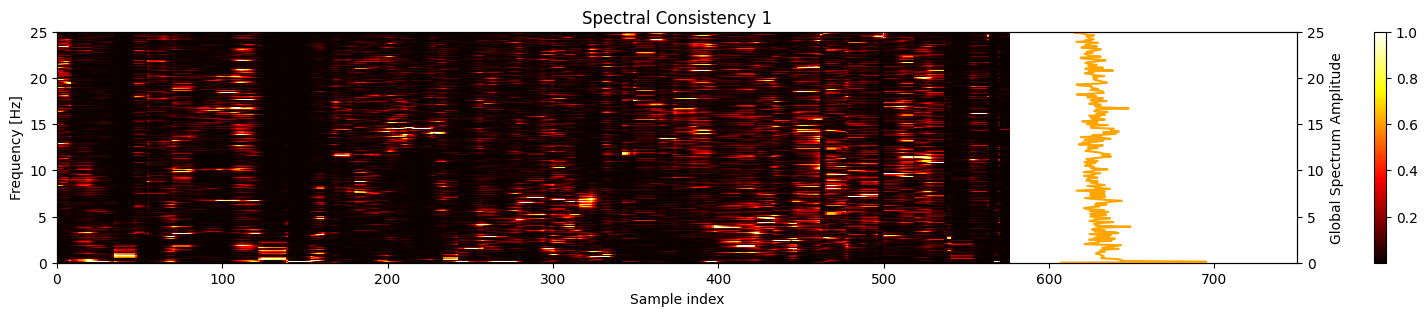

In [21]:
flim = (0, 25)  # Frequency limit for spectral consistency plot
ax = plot_spectrogram((f, t, C_spectral), tlim=(0, tmax), flim=flim, title='Spectral Consistency 1', spatial=False, x_index=True)
# calculate global spectrum as mean along time
global_spectral_spectrum = np.mean(C_spectral, axis=1)
# add a right subplot and plot it vertically at the right side of the plot
ax_twin = ax.twinx()
scale = 500
ax_twin.plot(scale*global_spectral_spectrum+600, f, label='Global Spectrum', color='orange')
ax_twin.set_ylim(flim)
ax_twin.set_ylabel('Global Spectrum Amplitude')

Text(0, 0.5, 'Global Spectrum Amplitude')

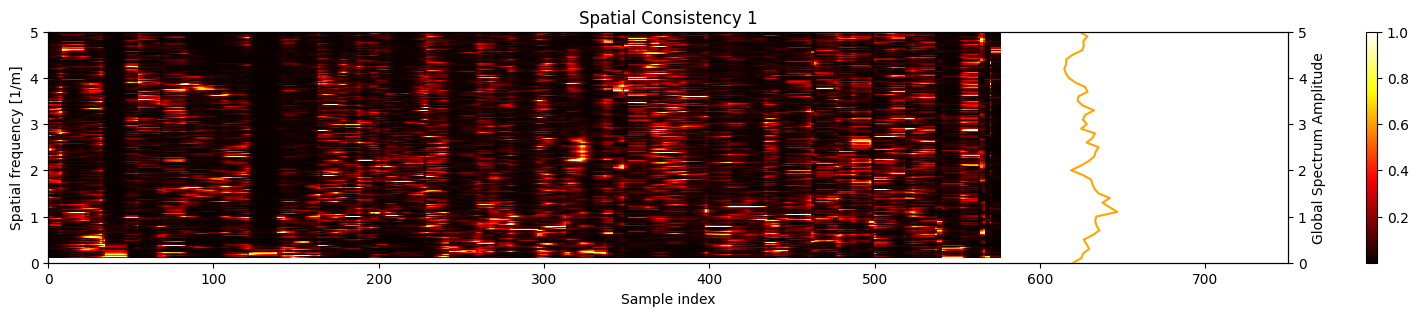

In [22]:
flim = (0, 5)  # Frequency limit for spatial consistency plot
ax = plot_spectrogram((fs, t, C_spatial), tlim=(0, tmax), flim=flim, title='Spatial Consistency 1', spatial=True, x_index=True)

# calculate global spectrum as mean along time
global_spatial_spectrum = np.mean(C_spatial, axis=1)
ax_twin = ax.twinx()
scale = 300
ax_twin.plot(scale*global_spatial_spectrum+600, f, label='Global Spectrum', color='orange')
ax_twin.set_ylim(flim)
ax_twin.set_ylabel('Global Spectrum Amplitude')


<Figure size 640x480 with 0 Axes>

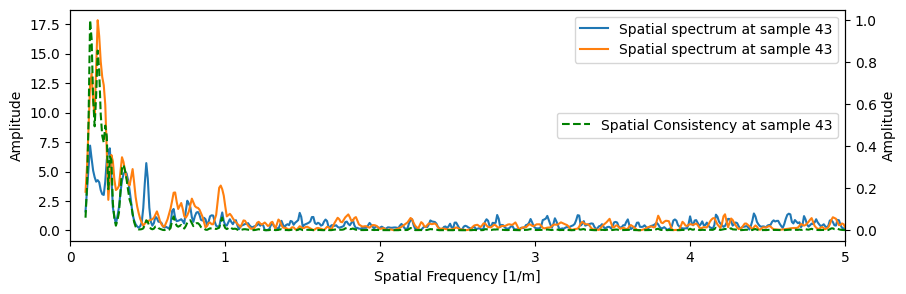

<Figure size 640x480 with 0 Axes>

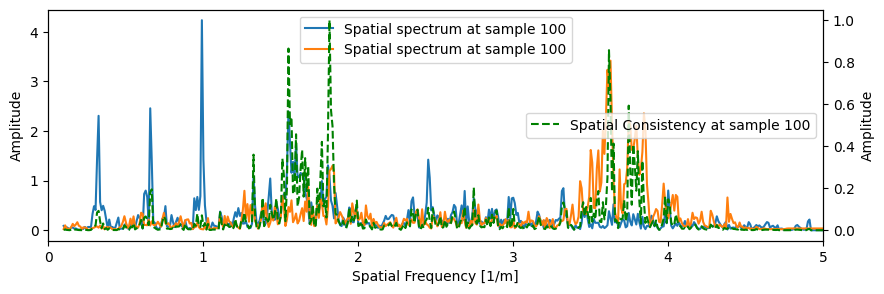

<Figure size 640x480 with 0 Axes>

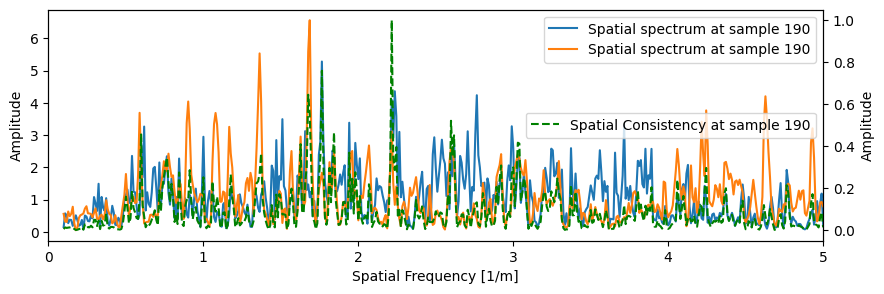

<Figure size 640x480 with 0 Axes>

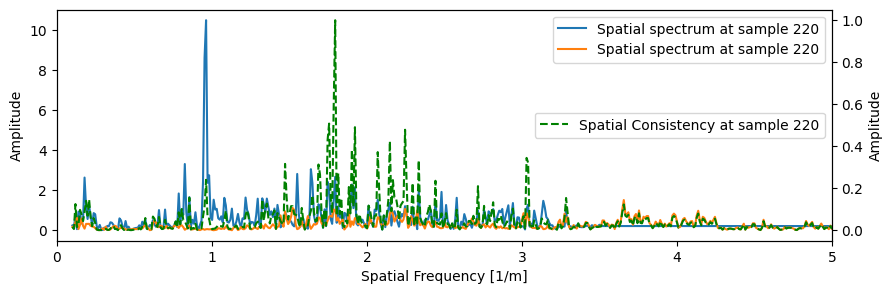

<Figure size 640x480 with 0 Axes>

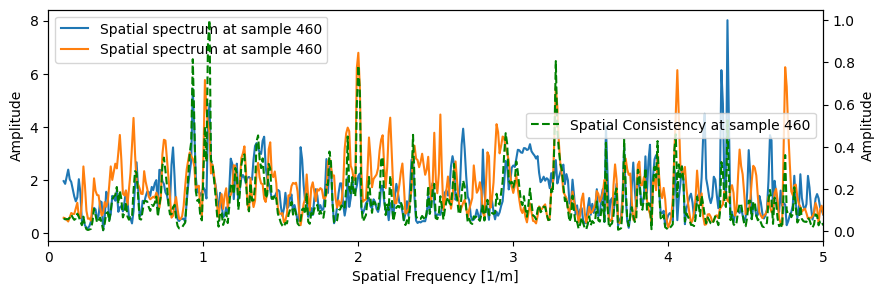

<Figure size 640x480 with 0 Axes>

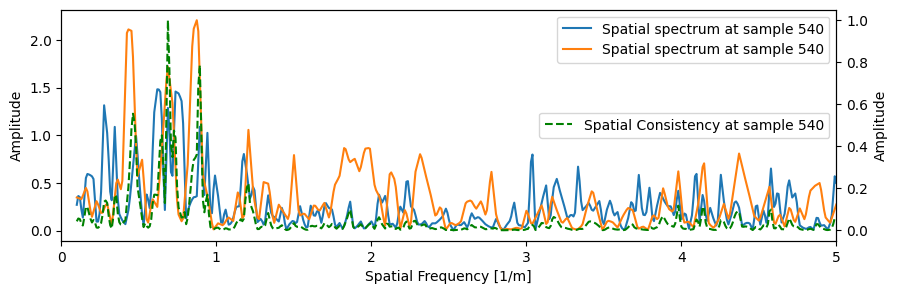

In [23]:
# plot slices of the spatial consistency at a given indexes
idx_ts = [43, 100, 190, 220, 460, 540]  # index
ax = None
flim = (0, 5)
for i, idx_t in enumerate(idx_ts):
    plt.figure()
    ax = plot_spectrum((fs, t, spatial_spectrogram_from_lf_1[2]), t_plot, ax=None, label=f'Spatial spectrum at sample {idx_t}', 
                       idx_t=idx_t, type_='spatial', flim=flim)
    ax = plot_spectrum((fs, t, spatial_spectrogram_from_lf_2_matched[2]), t_plot, ax=ax, label=f'Spatial spectrum at sample {idx_t}', 
                       idx_t=idx_t, type_='spatial', flim=flim)
    ax_ = plot_spectrum((fs, t, C_spatial), t_plot, ax=ax.twinx(), linestyle='--', label=f'Spatial Consistency at sample {idx_t}', 
                       idx_t=idx_t, type_='spatial', color='green', flim=flim)
    ax_.legend(loc='right')


In [10]:
arr = np.array([[1,2,3],
                [4,5,6]])
print(arr)
print(list(arr))

for a in arr:
    print(a)

[[1 2 3]
 [4 5 6]]
[array([1, 2, 3]), array([4, 5, 6])]
[1 2 3]
[4 5 6]
